In [54]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [65]:
# Data Organization for Visualization
path = "/home/jinsu/project/sdofmv2/assets/ds_results/f107/"
df_sdofmv1 = pd.read_csv(path + "f107_results_sdofmv1_cross_attn.csv")
df_sdofmv1["timestamp"] = pd.to_datetime(df_sdofmv1["timestamp"], unit="ns")

# sdofmv2
df_sdofmv2_all = pd.read_csv(path + "f107_results_ALL_cross_attn.csv")
df_sdofmv2_all["timestamp"] = pd.to_datetime(df_sdofmv2_all["timestamp"], unit="ns")

# solaris
df_solaris = pd.read_csv(path + "test_results_solaris.csv")
df_solaris["timestamp"] = pd.to_datetime(df_solaris["date"])

# solaris
df_surya = pd.read_csv(path + "test_results_surya.csv")
df_surya["timestamp"] = pd.to_datetime(df_surya["timestamp"], unit="ns")

# f10.7 data
df_data = pd.read_csv("/home/jinsu/project/sdofmv2/assets/cache/f10.7.csv")

# inverse transformation of label/prediction
max_val = df_data[" f107"].max()
df_sdofmv1["label_denorm"] = df_sdofmv1["label"] * max_val
df_sdofmv1["prediction_denorm"] = df_sdofmv1["prediction"] * max_val

df_sdofmv2_all["label_denorm"] = df_sdofmv2_all["label"] * max_val
df_sdofmv2_all["prediction_denorm"] = df_sdofmv2_all["prediction"] * max_val

df_surya["label_denorm"] = df_surya["label"] * max_val
df_surya["prediction_denorm"] = df_surya["prediction"] * max_val

In [66]:
# Sort all dataframes by timestamp
df_sdofmv1 = df_sdofmv1.sort_values('timestamp')
df_sdofmv2_all = df_sdofmv2_all.sort_values('timestamp')
df_solaris = df_solaris.sort_values('timestamp')
df_surya = df_surya.sort_values('timestamp')

# Add suffixes to prevent column collisions, but keep the 'timestamp' column name pure
df_sdofmv1 = df_sdofmv1.add_suffix('_sdofmv1').rename(columns={'timestamp_sdofmv1': 'timestamp'})
df_sdofmv2 = df_sdofmv2_all.add_suffix('_sdofmv2').rename(columns={'timestamp_sdofmv2': 'timestamp'})
df_solaris = df_solaris.add_suffix('_solaris').rename(columns={'timestamp_solaris': 'timestamp'})
df_surya = df_surya.add_suffix('_surya').rename(columns={'timestamp_surya': 'timestamp'})

# Merge sequentially using df_sdofmv1 as the "Master Timeline"
# direction="nearest" finds the closest time (forward or backward) within the 12-minute window.
tol = pd.Timedelta('12min')

df_merged = pd.merge_asof(df_sdofmv1, df_sdofmv2, on="timestamp", tolerance=tol, direction="nearest")
df_merged = pd.merge_asof(df_merged, df_solaris, on="timestamp", tolerance=tol, direction="nearest")
df_merged = pd.merge_asof(df_merged, df_surya, on="timestamp", tolerance=tol, direction="nearest")
df_merged.dropna(inplace=True)

In [67]:
df_merged

,timestamp,label_sdofmv1,prediction_sdofmv1,label_denorm_sdofmv1,prediction_denorm_sdofmv1,label_sdofmv2,prediction_sdofmv2,label_denorm_sdofmv2,prediction_denorm_sdofmv2,Unnamed: 0_solaris,date_solaris,target_solaris,prediction_raw_solaris,error_solaris,label_surya,prediction_surya,label_denorm_surya,prediction_denorm_surya
2,2010-10-03 00:00:00,0.218256,0.225774,80.100000,82.859180,0.218256,0.242201,80.100000,88.887745,1.0,2010-10-03 00:00:00,80.100000,88.166016,8.066016,0.218256,0.218750,80.100000,80.281250
3,2010-10-04 00:00:00,0.207357,0.216020,76.099999,79.279516,0.207357,0.216488,76.099999,79.451054,3.0,2010-10-04 00:00:00,76.099999,83.506836,7.406837,0.207357,0.213867,76.099999,78.489258
4,2010-10-05 00:00:00,0.205450,0.205723,75.400002,75.500408,0.205450,0.214115,75.400002,78.580082,5.0,2010-10-05 00:00:00,75.400002,81.714844,6.314842,0.205450,0.211914,75.400002,77.772461
7,2010-10-09 00:00:00,0.207629,0.210244,76.200000,77.159548,0.207629,0.234132,76.200000,85.926397,10.0,2010-10-09 00:00:00,76.200000,79.922852,3.722852,0.207629,0.212891,76.200000,78.130859
8,2010-10-10 00:00:00,0.206267,0.213202,75.700000,78.245030,0.206267,0.229032,75.700000,84.054912,12.0,2010-10-10 00:00:00,75.700000,76.338867,0.638868,0.206267,0.213867,75.700000,78.489258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,2017-12-27 00:12:00,0.186921,0.198118,68.600002,72.709399,0.186921,0.193814,68.600002,71.129676,1339.0,2017-12-27 00:00:00,68.600002,75.980469,7.380467,0.186921,0.201172,68.600002,73.830078
668,2017-12-28 00:12:00,0.187466,0.195157,68.799998,71.622747,0.187466,0.192240,68.799998,70.552167,1341.0,2017-12-28 00:00:00,68.799998,75.263672,6.463673,0.187466,0.200195,68.799998,73.471680
669,2017-12-29 00:12:00,0.188283,0.189703,69.100002,69.620893,0.188283,0.191490,69.100002,70.276970,1343.0,2017-12-29 00:00:00,69.100002,75.622070,6.522068,0.188283,0.199219,69.100002,73.113281
670,2017-12-30 00:12:00,0.185559,0.184713,68.100002,67.789848,0.185559,0.187791,68.100002,68.919392,1345.0,2017-12-30 00:00:00,68.100002,75.980469,7.880467,0.185559,0.199219,68.100002,73.113281


In [68]:
target = df_merged["label_denorm_sdofmv1"]
r2_sdofmv1 = r2_score(target, df_merged["prediction_denorm_sdofmv1"])
r2_sdofmv2_all = r2_score(target, df_merged["prediction_denorm_sdofmv2"])
r2_solaris = r2_score(target, df_merged["prediction_raw_solaris"])
r2_surya = r2_score(target, df_merged["prediction_denorm_surya"])


mae_sdofmv1 = mean_absolute_error(target, df_merged["prediction_denorm_sdofmv1"])
mae_sdofmv2_all = mean_absolute_error(target, df_merged["prediction_denorm_sdofmv2"])
mae_solaris = mean_absolute_error(target, df_merged["prediction_raw_solaris"])
mae_surya = mean_absolute_error(target, df_merged["prediction_denorm_surya"])


mse_sdofmv1 = mean_squared_error(target, df_merged["prediction_denorm_sdofmv1"])
mse_sdofmv2_all = mean_squared_error(target, df_merged["prediction_denorm_sdofmv2"])
mse_solaris = mean_squared_error(target, df_merged["prediction_raw_solaris"])
mse_surya = mean_squared_error(target, df_merged["prediction_denorm_surya"])

print(f"SDOFMV1, MAE: {mae_sdofmv1:.2f}, MSE: {mse_sdofmv1:.2f}, R-sqaured: {r2_sdofmv1:.4f}")
print(f"SDOFMV2_ALL, MAE: {mae_sdofmv2_all:.2f}, MSE: {mse_sdofmv2_all:.2f}, R-sqaured: {r2_sdofmv2_all:.4f}")
print(f"Solaris, MAE: {mae_solaris:.2f}, MSE: {mse_solaris:.2f}, R-sqaured: {r2_solaris:.4f}")
print(f"Surya, MAE: {mae_surya:.2f}, MSE: {mse_surya:.2f}, R-sqaured: {r2_surya:.4f}")


SDOFMV1, MAE: 5.87, MSE: 77.57, R-sqaured: 0.9243
SDOFMV2_ALL, MAE: 7.01, MSE: 110.45, R-sqaured: 0.8922
Solaris, MAE: 7.66, MSE: 134.03, R-sqaured: 0.8692
Surya, MAE: 6.52, MSE: 84.33, R-sqaured: 0.9177


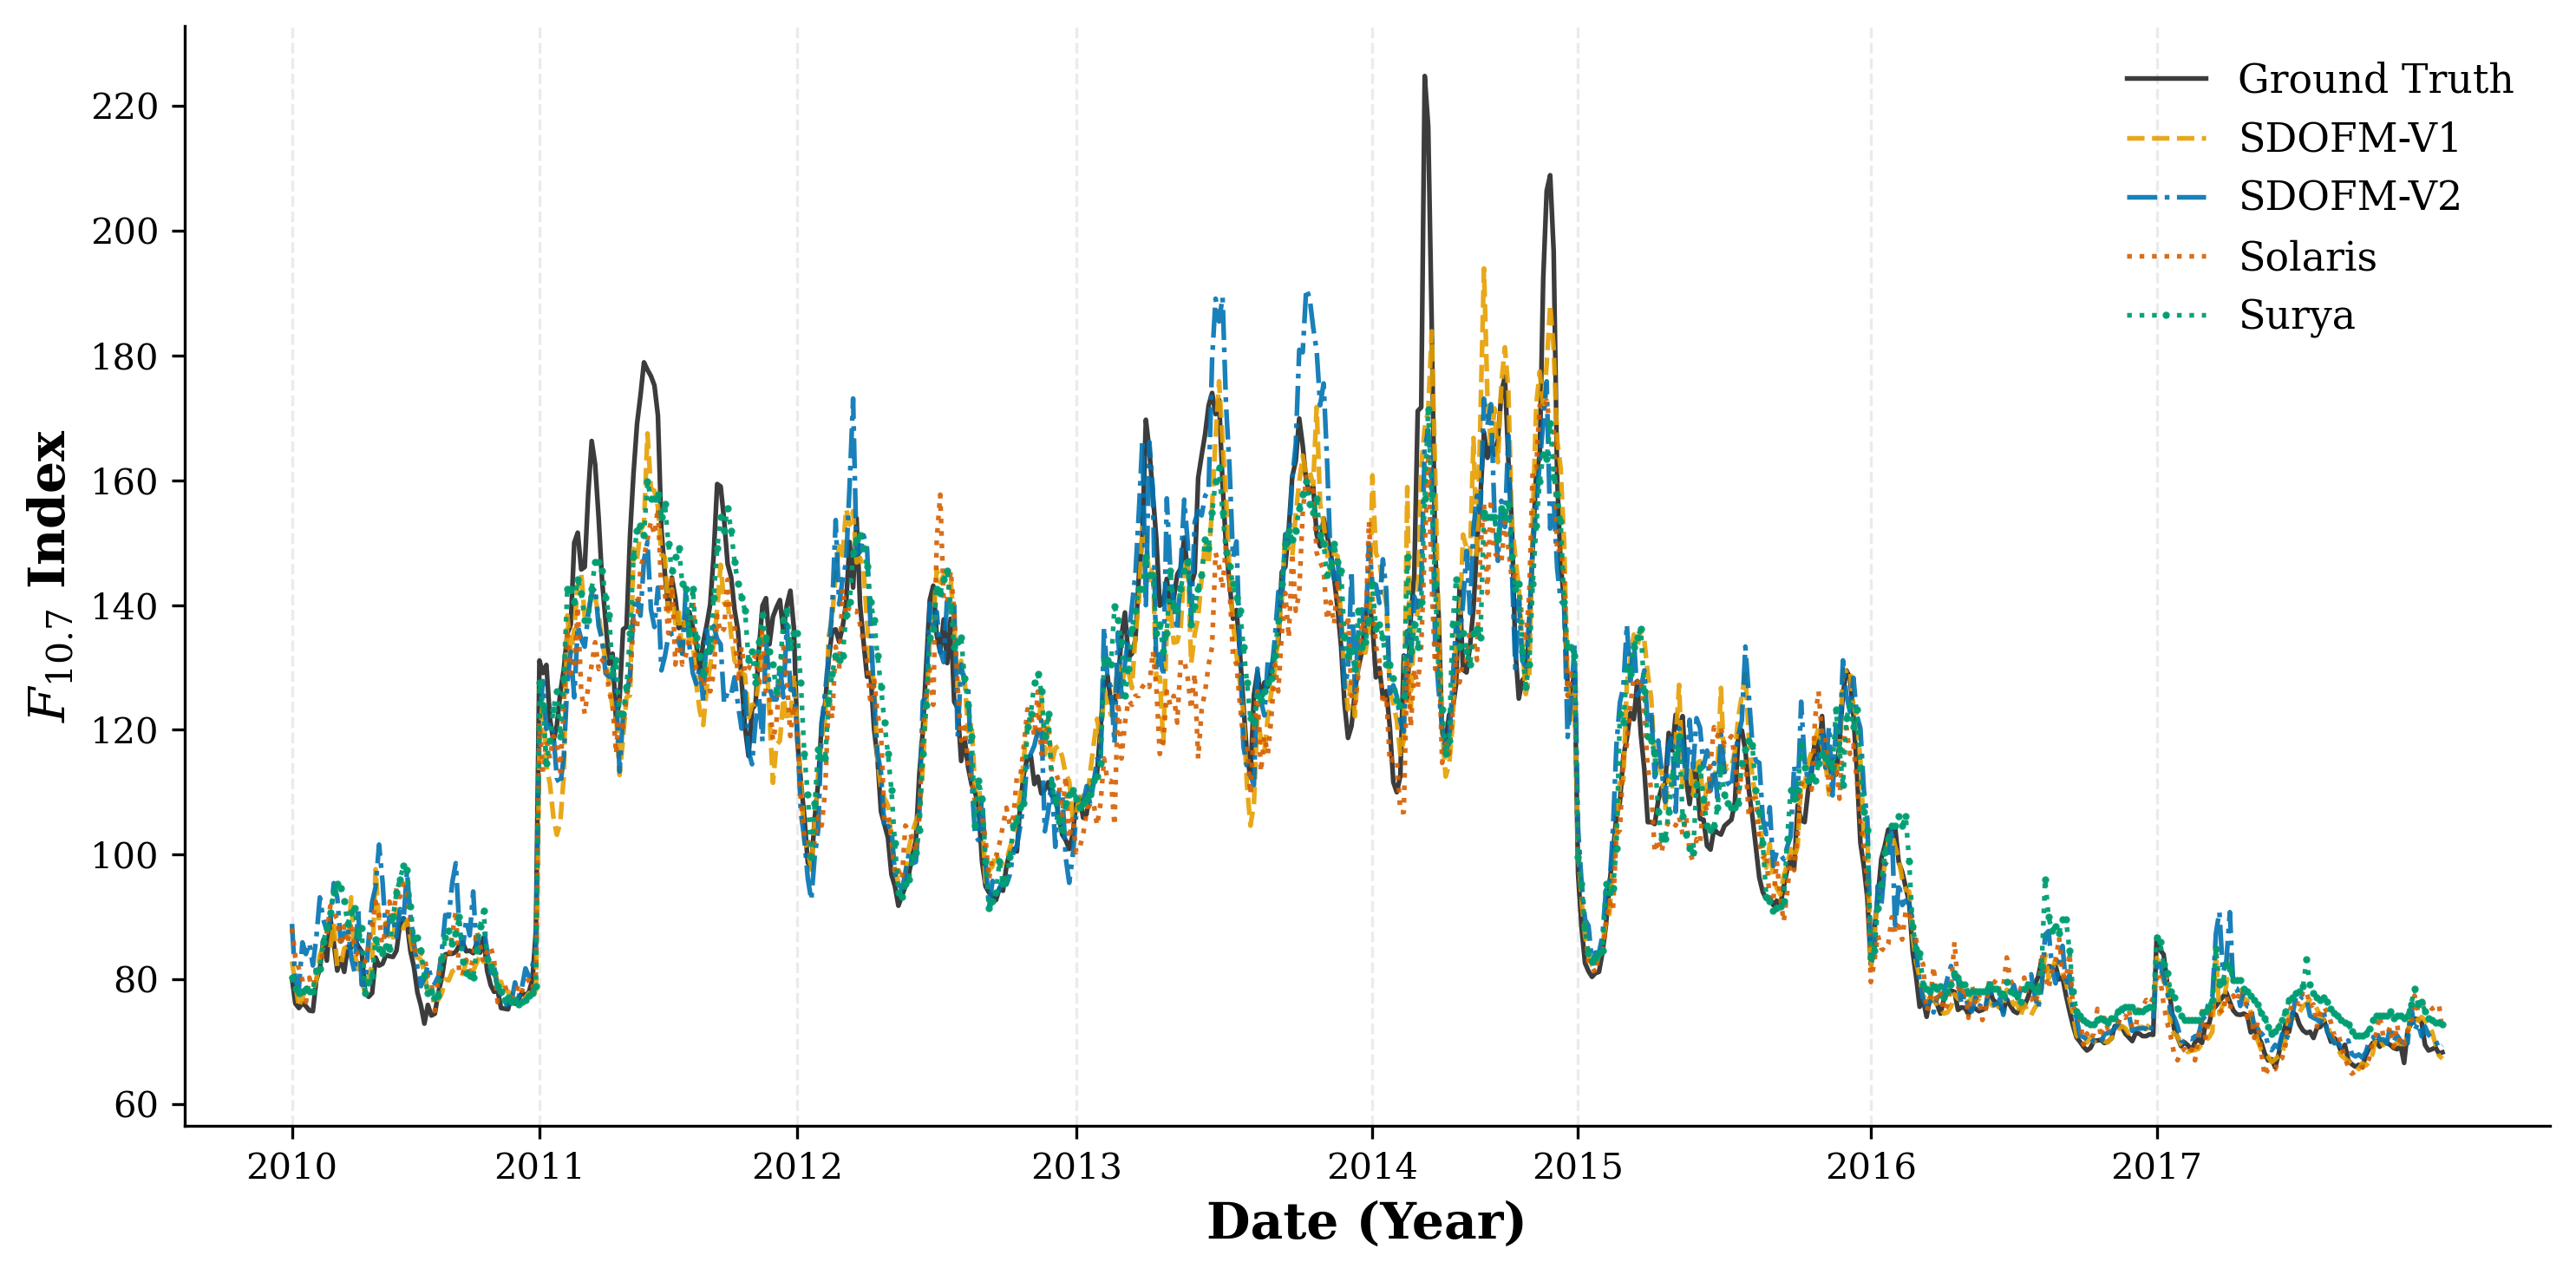

In [69]:
dates = pd.to_datetime(df_merged["timestamp"])
years = dates.dt.year
x_v1 = np.arange(len(dates))

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Ground Truth (strong reference)
ax.plot(
    x_v1, target,
    label="Ground Truth",
    color='#1a1a1a',
    linewidth=1.3,
    alpha=0.85
)

# SDOMF-V1 (Okabe-Ito Orange)
ax.plot(
    x_v1, df_merged["prediction_denorm_sdofmv1"],
    label="SDOFM-V1",
    color='#E69F00',
    linewidth=1.3,
    linestyle='--',
    alpha=0.90
)

# SDOMF-V2 (Okabe-Ito Blue)
ax.plot(
    x_v1, df_merged["prediction_denorm_sdofmv2"],
    label="SDOFM-V2",
    color='#0072B2',
    linewidth=1.3,
    linestyle='-.',
    alpha=0.90
)

# Solaris (replace neon green → muted red)
ax.plot(
    x_v1, df_merged["prediction_raw_solaris"],
    label="Solaris",
    color='#D55E00',
    linewidth=1.3,
    linestyle=':',
    alpha=0.90
)

# Solaris (replace neon green → muted red)
ax.plot(
    x_v1, df_merged["prediction_denorm_surya"],
    label="Surya",
    color='#009E73',
    linewidth=1.3,
    linestyle=':',
    marker=".",
    markersize=2,
    alpha=0.95
)

ax.set_xlabel("Date (Year)", fontsize=14, fontweight='bold')
ax.set_ylabel(r"$F_{10.7}$ Index", fontsize=14, fontweight='bold')

unique_years, indices = np.unique(years, return_index=True)
ax.set_xticks(indices)
ax.set_xticklabels(unique_years)

# Clean journal style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, axis='x', linestyle='--', alpha=0.25)

ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig("f107_result_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()